In [120]:
import pandas as pd 
import numpy as np

In [121]:
df = pd.read_csv("titanic.csv")

In [122]:
df

,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S
2,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S
3,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S
4,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S
...,...,...,...,...,...,...,...,...,...,...
1304,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C
1305,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C
1306,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C
1307,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C


In [123]:
df.sum()

survived                                                  500
name        Allen, Miss. Elisabeth WaltonAllison, Master. ...
sex         femalemalefemalemalefemalemalefemalemalefemale...
age                                                31255.6667
sibsp                                                     653
parch                                                     504
ticket      2416011378111378111378111378119952135021120501...
fare                                               43550.4869
cabin       B5C22 C26C22 C26C22 C26C22 C26E12D7A36C101C62 ...
embarked    SSSSSSSSSCCCCSSSCCCCSSCCSCCCSSSCSSSCSSSCCCSCCS...
dtype: object

In [124]:
survived = df["survived"].sum()
survived

np.int64(500)

In [125]:
dead = (df["survived"] == 0).sum()
dead

np.int64(809)

In [126]:
#PRedict
#Total correct / total
dead / (dead + survived)

np.float64(0.6180290297937356)

In [127]:
titanic_feature = ["sex","age","sibsp","parch","fare"]
X = df[titanic_feature]


In [128]:
X = pd.get_dummies(X,drop_first=True)

In [129]:
X

,age,sibsp,parch,fare,sex_male
0,29.0000,0,0,211.3375,False
1,0.9167,1,2,151.5500,True
2,2.0000,1,2,151.5500,False
3,30.0000,1,2,151.5500,True
4,25.0000,1,2,151.5500,False
...,...,...,...,...,...
1304,14.5000,1,0,14.4542,False
1305,NaN,1,0,14.4542,False
1306,26.5000,0,0,7.2250,True
1307,27.0000,0,0,7.2250,True


In [130]:
X.isna().sum()

age         263
sibsp         0
parch         0
fare          1
sex_male      0
dtype: int64

In [131]:
X["age"] = X["age"].fillna(X["age"].mean())

In [132]:
X.isna().sum()

age         0
sibsp       0
parch       0
fare        1
sex_male    0
dtype: int64

In [133]:
X["fare"] = X["fare"].ffill()

In [134]:
X.isna().sum()

age         0
sibsp       0
parch       0
fare        0
sex_male    0
dtype: int64

In [135]:
X.describe()

,age,sibsp,parch,fare
count,1309.000000,1309.000000,1309.000000,1309.000000
mean,29.881135,0.498854,0.385027,33.276193
std,12.883199,1.041658,0.865560,51.743584
min,0.166700,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.895800
50%,29.881135,0.000000,0.000000,14.454200
75%,35.000000,1.000000,0.000000,31.275000
max,80.000000,8.000000,9.000000,512.329200


In [136]:
y = df["survived"]

In [137]:
all_data = pd.concat([y,X],axis = 1)

In [138]:
all_data

,survived,age,sibsp,parch,fare,sex_male
0,1,29.000000,0,0,211.3375,False
1,1,0.916700,1,2,151.5500,True
2,0,2.000000,1,2,151.5500,False
3,0,30.000000,1,2,151.5500,True
4,0,25.000000,1,2,151.5500,False
...,...,...,...,...,...,...
1304,0,14.500000,1,0,14.4542,False
1305,0,29.881135,1,0,14.4542,False
1306,0,26.500000,0,0,7.2250,True
1307,0,27.000000,0,0,7.2250,True


In [139]:
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_predict,cross_val_score,train_test_split
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay


In [ ]:
data_train, data_test = train_test_split(all_data, test_size=0.2,random_state=32)

In [141]:
X_train = data_train.drop("survived",axis =1)
y_train = data_train["survived"]
X_test = data_test.drop("survived", axis = 1)
y_test = data_test["survived"]

In [142]:
LR = LogisticRegression()

In [143]:
LR.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [144]:
y_pred = LR.predict(X_test)

In [145]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.85      0.80       145
           1       0.78      0.66      0.71       117

    accuracy                           0.76       262
   macro avg       0.77      0.75      0.76       262
weighted avg       0.76      0.76      0.76       262



In [146]:
cm = confusion_matrix(y_test,y_pred)

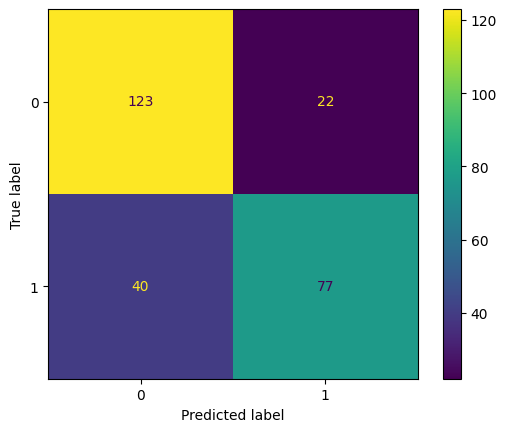

In [147]:
ConfusionMatrixDisplay(cm).plot()

In [148]:
precision = cross_val_score(LR, X, y = y,cv = 10)
precision.mean()

np.float64(0.7738696418085731)

In [149]:
import seaborn as sns

<Axes: >

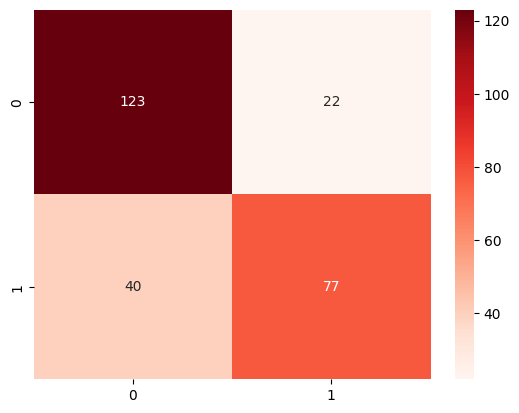

In [150]:
sns.heatmap(cm, annot=True,cmap="Reds",fmt="d")

In [151]:
titanic_feature


['sex', 'age', 'sibsp', 'parch', 'fare']

In [152]:
new_passenger = [[True,28,3,0,100]]

In [153]:
LR.predict(new_passenger)

c:\Users\kirit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])